In [116]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import layers, models, callbacks, losses
import warnings
warnings.filterwarnings('ignore')

In [117]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [118]:
# ============================================================================
# 1. 데이터 로딩
# ============================================================================

def load_data(mat_path, use_ecg=False):
    """PPG (+ ECG) 신호와 혈압 로드"""
    with h5py.File(mat_path, 'r') as f:
        ppg_refs = f['Subj_Wins']['PPG_F'][0]
        sbp_refs = f['Subj_Wins']['SegSBP'][0]
        dbp_refs = f['Subj_Wins']['SegDBP'][0]

        ppg_list, sbp_list, dbp_list = [], [], []
        ecg_list = [] if use_ecg else None

        if use_ecg:
            ecg_refs = f['Subj_Wins']['ECG_F'][0]

        for i in range(len(ppg_refs)):
            ppg = f[ppg_refs[i]][()].squeeze().astype(np.float32)
            sbp = float(f[sbp_refs[i]][()][0][0])
            dbp = float(f[dbp_refs[i]][()][0][0])

            ppg_list.append(ppg)
            sbp_list.append(sbp)
            dbp_list.append(dbp)

            if use_ecg:
                ecg = f[ecg_refs[i]][()].squeeze().astype(np.float32)
                ecg_list.append(ecg)

    # 배열로 변환
    X_ppg = np.array(ppg_list)
    y = np.column_stack([sbp_list, dbp_list])

    if use_ecg:
        X_ecg = np.array(ecg_list)
        X = np.stack([X_ppg, X_ecg], axis=-1)  # (N, 1250, 2)
    else:
        X = X_ppg  # (N, 1250)

    return X, y

In [119]:
# ============================================================================
# 5-Fold 분할
# ============================================================================

def create_5fold(N):
    fold_size = N // 5
    splits = []
    for i in range(5):
        start = i * fold_size
        end = N if i == 4 else start + fold_size
        train_idx = list(range(start, min(start+320, end)))
        val_idx = list(range(start+320, min(start+360, end)))
        test_idx = list(range(start+360, min(start+400, end)))
        splits.append((train_idx, val_idx, test_idx))
    return splits


In [120]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Reshape

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))


In [121]:
# ============================================================================
# 1. 한 Fold의 데이터 나누기
# ============================================================================
def get_fold_data(X, y, train_idx, val_idx, test_idx):
    X_train, y_train = X[train_idx], y[train_idx]
    X_val,   y_val   = X[val_idx],   y[val_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]
    return X_train, y_train, X_val, y_val, X_test, y_test

In [122]:
# ============================================================================
# 2. 입력 X 정규화 (개선 버전)
#    - 2D (N, F) : 기존처럼 StandardScaler (feature-wise, train 기준)
#    - 3D (N, T, C) : 샘플별(z-score) 정규화
#      -> 각 윈도우마다 (전체 시점/채널 평균 0, 표준편차 1)
# ============================================================================

def normalize_X(X_train, X_val, X_test, eps=1e-8):
    scaler = StandardScaler()

    # 2D tabular 형태 (예: (N, F))
    if X_train.ndim == 2:
        X_train_n = scaler.fit_transform(X_train)
        X_val_n   = scaler.transform(X_val)
        X_test_n  = scaler.transform(X_test)
        return X_train_n, X_val_n, X_test_n

    # 3D 시계열 형태 (예: (N, T, C) 또는 (N, T))
    # 샘플별 정규화: 각 윈도우마다 평균 0, 표준편차 1 로 맞춤
    # -> 환자별/윈도우별 베이스라인 차이를 줄여 cross-patient 일반화에 도움
    def normalize_per_sample(X):
        # X: (N, T, C) or (N, T)
        if X.ndim == 2:
            # (N, T) -> (N, T, 1) 로 맞춰서 처리
            X = X[..., np.newaxis]  # (N, T, 1)

        # (N, T, C)
        mean = X.mean(axis=(1, 2), keepdims=True)        # (N,1,1)
        std  = X.std(axis=(1, 2), keepdims=True) + eps   # (N,1,1)
        X_n  = (X - mean) / std
        return X_n

    X_train_n = normalize_per_sample(X_train)
    X_val_n   = normalize_per_sample(X_val)
    X_test_n  = normalize_per_sample(X_test)

    # 만약 모델이 (T,)나 (T,C)를 기대한다면, 마지막 채널 차원이 1인 경우 다시 squeeze 해도 됨
    # 여기서는 (N, T, C) 형태 그대로 두는 걸 가정 (Conv1D 입력에 맞춤)
    return X_train_n, X_val_n, X_test_n


In [123]:
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, Flatten, Dense,
    BatchNormalization, LSTM, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [124]:
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, Dense,
    GlobalAveragePooling1D, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model_ppg(input_shape):
    """
    input_shape: (T,)  예) (1250,)
    PPG 한 채널용 단순 CNN 회귀 모델
    """
    inp = Input(shape=input_shape, name="ppg_input")      # (T,)
    x = Reshape((input_shape[0], 1), name="ppg_reshape")(inp)  # (T, 1)

    # Conv 블록 1
    x = Conv1D(32, kernel_size=5, activation='relu', padding='same',
               name="ppg_conv1")(x)
    x = MaxPooling1D(pool_size=2, name="ppg_pool1")(x)

    # Conv 블록 2
    x = Conv1D(64, kernel_size=5, activation='relu', padding='same',
               name="ppg_conv2")(x)
    x = MaxPooling1D(pool_size=2, name="ppg_pool2")(x)

    # Flatten 대신 GlobalAveragePooling -> 파라미터 수 감소 + 과적합 완화
    x = GlobalAveragePooling1D(name="ppg_gap")(x)

    # 작은 Dense 한 층
    x = Dense(32, activation='relu', name="ppg_fc1")(x)
    x = Dropout(0.2, name="ppg_drop1")(x)

    out = Dense(2, name="ppg_out")(x)   # [SBP, DBP]

    model = Model(inp, out, name="PPG_SimpleCNN")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mae',
        metrics=[rmse]   # 기존에 정의해 둔 rmse 함수
    )
    return model


In [125]:
def build_model_ecg_ppg(input_shape):
    """
    input_shape: (T, C)  예) (1250, 2)
    ECG + PPG 같은 다채널 입력용 단순 CNN 회귀 모델
    """
    inp = Input(shape=input_shape, name="ecg_ppg_input")   # (T, C)

    # Conv 블록 1
    x = Conv1D(32, kernel_size=5, activation='relu', padding='same',
               name="ecgppg_conv1")(inp)
    x = MaxPooling1D(pool_size=2, name="ecgppg_pool1")(x)

    # Conv 블록 2
    x = Conv1D(64, kernel_size=5, activation='relu', padding='same',
               name="ecgppg_conv2")(x)
    x = MaxPooling1D(pool_size=2, name="ecgppg_pool2")(x)

    # GlobalAveragePooling1D
    x = GlobalAveragePooling1D(name="ecgppg_gap")(x)

    # 작은 Dense 한 층
    x = Dense(32, activation='relu', name="ecgppg_fc1")(x)
    x = Dropout(0.2, name="ecgppg_drop1")(x)

    out = Dense(2, name="ecgppg_out")(x)   # [SBP, DBP]

    model = Model(inp, out, name="ECG_PPG_SimpleCNN")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mae',
        metrics=[rmse]
    )
    return model


In [126]:
# ============================================================================
# 3. 한 Fold 학습
# ============================================================================
def train_one_fold(X_train, y_train, X_val, y_val, build_fn):
    model = build_fn(X_train.shape[1:])   # ← 어떤 모델을 쓸지 함수로 받음

    es = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )
    return model


In [127]:
# ============================================================================
# 4. 한 Fold 평가
# ============================================================================
def evaluate_one_fold(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)

    sbp_mae  = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
    dbp_mae  = mean_absolute_error(y_test[:, 1], y_pred[:, 1])
    sbp_rmse = np.sqrt(mean_squared_error(y_test[:, 0], y_pred[:, 0]))
    dbp_rmse = np.sqrt(mean_squared_error(y_test[:, 1], y_pred[:, 1]))

    return sbp_mae, dbp_mae, sbp_rmse, dbp_rmse

In [128]:
# ============================================================================
# 5. 5-Fold 교차 검증 (메인 루프)
# ============================================================================
def run_5fold(X, y, build_fn, model_name="Model"):
    N = len(X)
    splits = create_5fold(N)
    results = []

    print(f"\n{'='*70}\n{model_name} - 5-Fold 교차 검증\n{'='*70}")

    for fold_i, (train_idx, val_idx, test_idx) in enumerate(splits, 1):
        if len(test_idx) == 0:
            continue

        print(f"\n[Fold {fold_i}] Train:{len(train_idx)} Val:{len(val_idx)} Test:{len(test_idx)}")

        X_train, y_train, X_val, y_val, X_test, y_test = get_fold_data(
            X, y, train_idx, val_idx, test_idx
        )

        X_train_n, X_val_n, X_test_n = normalize_X(X_train, X_val, X_test)

        model = train_one_fold(X_train_n, y_train, X_val_n, y_val, build_fn)

        sbp_mae, dbp_mae, sbp_rmse, dbp_rmse = evaluate_one_fold(
            model, X_test_n, y_test
        )

        results.append({
            'Fold': f'Fold {fold_i}',
            'Train': len(train_idx),
            'Val': len(val_idx),
            'Test': len(test_idx),
            'SBP_MAE': round(sbp_mae, 3),
            'DBP_MAE': round(dbp_mae, 3),
            'SBP_RMSE': round(sbp_rmse, 3),
            'DBP_RMSE': round(dbp_rmse, 3)
        })

        print(f"  SBP: MAE={sbp_mae:.3f}, RMSE={sbp_rmse:.3f}")
        print(f"  DBP: MAE={dbp_mae:.3f}, RMSE={dbp_rmse:.3f}")

    if results:
        sbp_mae_list  = [r['SBP_MAE']  for r in results]
        dbp_mae_list  = [r['DBP_MAE']  for r in results]
        sbp_rmse_list = [r['SBP_RMSE'] for r in results]
        dbp_rmse_list = [r['DBP_RMSE'] for r in results]

        results.append({
            'Fold': 'Mean & Std',
            'Train': '-', 'Val': '-', 'Test': '-',
            'SBP_MAE':  f"mean={np.mean(sbp_mae_list):.2f}, std={np.std(sbp_mae_list):.2f}",
            'DBP_MAE':  f"mean={np.mean(dbp_mae_list):.2f}, std={np.std(dbp_mae_list):.2f}",
            'SBP_RMSE': f"mean={np.mean(sbp_rmse_list):.2f}, std={np.std(sbp_rmse_list):.2f}",
            'DBP_RMSE': f"mean={np.mean(dbp_rmse_list):.2f}, std={np.std(dbp_rmse_list):.2f}"
        })

    df = pd.DataFrame(results)
    print(f"\n{'='*70}\n최종 결과\n{'='*70}")
    print(df.to_string(index=False))

    return df, sbp_mae_list, dbp_mae_list, sbp_rmse_list, dbp_rmse_list


In [129]:
# ============================================================================
# 환자 간 테스트 (train_path 환자로 학습, test_path 환자로 테스트)
#   - 모델: build_model_ppg / build_model_ecg_ppg 재사용
#   - 정규화: normalize_X 재사용
#   - 학습/평가: train_one_fold, evaluate_one_fold 재사용
#   - 5-Fold는 "훈련 환자" 데이터만 나누고,
#     테스트는 항상 "테스트 환자 전체"를 사용해서 cross-patient 성능을 본다.
# ============================================================================

def cross_patient_test(train_path, test_path, use_ecg=False):
    """
    train_path 환자 데이터로 모델을 학습하고,
    test_path 환자 데이터 전체에 대해 성능을 평가하는 cross-patient 테스트.

    - use_ecg=False : PPG only (build_model_ppg)
    - use_ecg=True  : ECG+PPG (build_model_ecg_ppg)

    반환:
        df              : fold별 결과 + 평균/표준편차 요약 DataFrame
        sbp_mae_list    : fold별 SBP MAE
        dbp_mae_list    : fold별 DBP MAE
        sbp_rmse_list   : fold별 SBP RMSE
        dbp_rmse_list   : fold별 DBP RMSE
    """
    model_name = "ECG+PPG" if use_ecg else "PPG only"
    print(f"\n{'='*70}\n환자 간 테스트 - {model_name}\n{'='*70}")

    # -----------------------------
    # 1. 데이터 로딩
    # -----------------------------
    X_train_all, y_train_all = load_data(train_path, use_ecg)
    X_test_all,  y_test_all  = load_data(test_path,  use_ecg)

    # 실험 통일을 위해 앞 2000개만 사용 (기존 코드와 동일한 제한 유지)
    X_train_all, y_train_all = X_train_all[:2000], y_train_all[:2000]
    X_test_all,  y_test_all  = X_test_all[:2000],  y_test_all[:2000]

    print(f"Train: {X_train_all.shape}, Test: {X_test_all.shape}")

    # 어떤 모델을 쓸지 선택
    build_fn = build_model_ecg_ppg if use_ecg else build_model_ppg

    # 훈련 환자 데이터 기준으로 5-Fold 분할
    N_train = len(X_train_all)
    splits = create_5fold(N_train)

    results = []
    sbp_mae_list, dbp_mae_list = [], []
    sbp_rmse_list, dbp_rmse_list = [], []

    print(f"\n{'-'*70}\n훈련 환자 기준 5-Fold, 테스트는 항상 다른 환자 전체\n{'-'*70}")

    for fold_i, (train_idx, val_idx, test_idx_unused) in enumerate(splits, 1):
        # 혹시라도 비어 있는 fold는 건너뛴다
        if len(train_idx) == 0 or len(val_idx) == 0:
            continue

        print(f"\n[Fold {fold_i}] Train:{len(train_idx)} Val:{len(val_idx)} Test:{len(X_test_all)}")

        # -----------------------------
        # 2. Fold별 Train / Val 구성
        #    (Test는 항상 다른 환자 전체)
        # -----------------------------
        X_tr, y_tr = X_train_all[train_idx], y_train_all[train_idx]
        X_val, y_val = X_train_all[val_idx], y_train_all[val_idx]

        # -----------------------------
        # 3. 정규화 (train 기준으로 val + test 스케일링)
        #    -> normalize_X 공통 함수 재사용
        # -----------------------------
        X_tr_n, X_val_n, X_te_n = normalize_X(X_tr, X_val, X_test_all)

        # -----------------------------
        # 4. 모델 학습 (train_one_fold 재사용)
        # -----------------------------
        model = train_one_fold(X_tr_n, y_tr, X_val_n, y_val, build_fn)

        # -----------------------------
        # 5. Cross-patient 평가
        #    (다른 환자 전체에 대해 평가)
        # -----------------------------
        sbp_mae, dbp_mae, sbp_rmse, dbp_rmse = evaluate_one_fold(
            model, X_te_n, y_test_all
        )

        sbp_mae_list.append(sbp_mae)
        dbp_mae_list.append(dbp_mae)
        sbp_rmse_list.append(sbp_rmse)
        dbp_rmse_list.append(dbp_rmse)

        results.append({
            'Fold': f'Fold {fold_i}',
            'Train': len(train_idx),
            'Val': len(val_idx),
            'Test': len(X_test_all),
            'SBP_MAE':  round(sbp_mae, 3),
            'DBP_MAE':  round(dbp_mae, 3),
            'SBP_RMSE': round(sbp_rmse, 3),
            'DBP_RMSE': round(dbp_rmse, 3),
        })

    # -----------------------------
    # 6. 평균 / 표준편차 요약 행 추가
    # -----------------------------
    if len(sbp_mae_list) > 0:
        results.append({
            'Fold': 'Mean ± Std',
            'Train': '-',
            'Val': '-',
            'Test': '-',
            'SBP_MAE':  f"{np.mean(sbp_mae_list):.3f}±{np.std(sbp_mae_list):.3f}",
            'DBP_MAE':  f"{np.mean(dbp_mae_list):.3f}±{np.std(dbp_mae_list):.3f}",
            'SBP_RMSE': f"{np.mean(sbp_rmse_list):.3f}±{np.std(sbp_rmse_list):.3f}",
            'DBP_RMSE': f"{np.mean(dbp_rmse_list):.3f}±{np.std(dbp_rmse_list):.3f}",
        })

    df = pd.DataFrame(results)
    print(f"\n{'='*70}\n최종 결과 - {model_name}\n{'='*70}")
    print(df.to_string(index=False))

    return df, sbp_mae_list, dbp_mae_list, sbp_rmse_list, dbp_rmse_list


In [130]:
# ============================================================================
# 그래프 그리기
# ============================================================================

def plot_results(mae_sbp, mae_dbp, rmse_sbp, rmse_dbp, title="Results"):
    """폴드별 결과를 막대 그래프로 시각화"""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    folds = [f'F{i}' for i in range(1, len(mae_sbp)+1)]

    # SBP MAE
    axes[0, 0].bar(folds, mae_sbp, color='#FF6B6B', alpha=0.7)
    axes[0, 0].axhline(y=np.mean(mae_sbp), color='red', linestyle='--',
                       label=f'Mean: {np.mean(mae_sbp):.3f}')
    axes[0, 0].set_title('SBP - MAE (mmHg)', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('MAE (mmHg)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # DBP MAE
    axes[0, 1].bar(folds, mae_dbp, color='#4ECDC4', alpha=0.7)
    axes[0, 1].axhline(y=np.mean(mae_dbp), color='blue', linestyle='--',
                       label=f'Mean: {np.mean(mae_dbp):.3f}')
    axes[0, 1].set_title('DBP - MAE (mmHg)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('MAE (mmHg)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # SBP RMSE
    axes[1, 0].bar(folds, rmse_sbp, color='#FF6B6B', alpha=0.7)
    axes[1, 0].axhline(y=np.mean(rmse_sbp), color='red', linestyle='--',
                       label=f'Mean: {np.mean(rmse_sbp):.3f}')
    axes[1, 0].set_title('SBP - RMSE (mmHg)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('RMSE (mmHg)')
    axes[1, 0].set_xlabel('Fold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # DBP RMSE
    axes[1, 1].bar(folds, rmse_dbp, color='#4ECDC4', alpha=0.7)
    axes[1, 1].axhline(y=np.mean(rmse_dbp), color='blue', linestyle='--',
                       label=f'Mean: {np.mean(rmse_dbp):.3f}')
    axes[1, 1].set_title('DBP - RMSE (mmHg)', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('RMSE (mmHg)')
    axes[1, 1].set_xlabel('Fold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

In [131]:
def plot_bp(y, title="Blood Pressure"):
    """혈압 시각화"""
    plt.figure(figsize=(15, 5))
    plt.plot(y[:, 0], 'r-', label='SBP', alpha=0.7, linewidth=1.5)
    plt.plot(y[:, 1], 'b-', label='DBP', alpha=0.7, linewidth=1.5)
    plt.xlabel('Segment', fontsize=12)
    plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



[단계 1] 데이터 로드 및 시각화
----------------------------------------------------------------------
✓ 데이터 로드 완료: (2000, 1250)


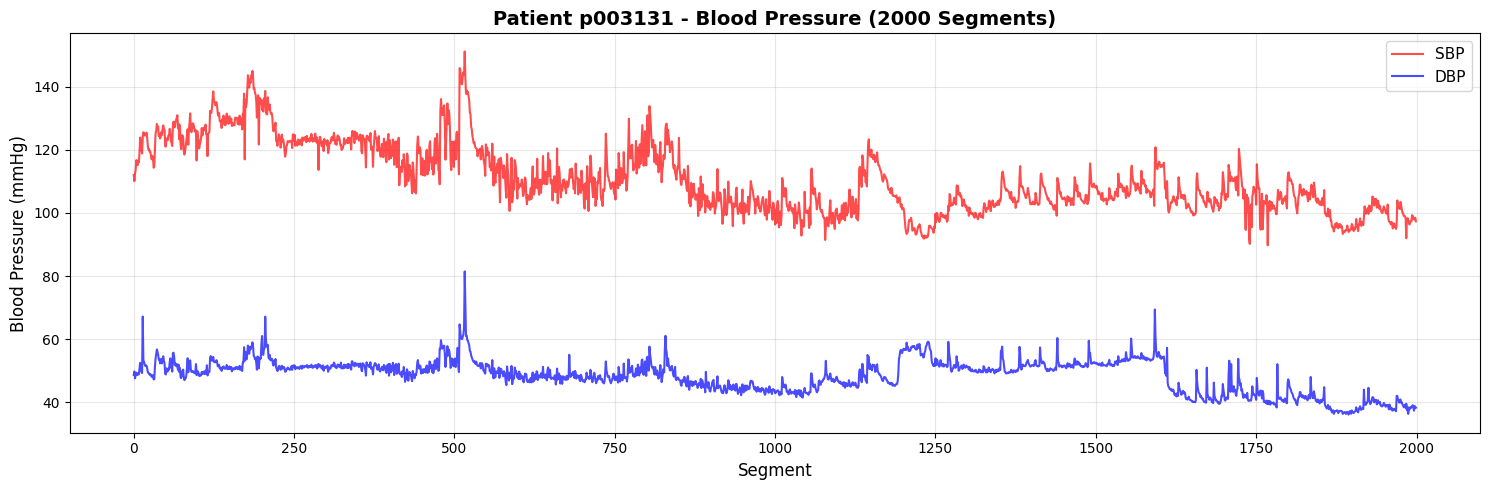

In [132]:
train_path = "/content/drive/MyDrive/p058008.mat"
test_path  = "/content/drive/MyDrive/p072847.mat"

# 1. 데이터 로드 및 시각화
print("\n[단계 1] 데이터 로드 및 시각화")
print("-"*70)

X_ppg, y_bp = load_data(train_path, use_ecg=False)
X_ppg = X_ppg[:2000]
y_bp  = y_bp[:2000]
print(f"✓ 데이터 로드 완료: {X_ppg.shape}")

plot_bp(y_bp, f"Patient p003131 - Blood Pressure ({len(y_bp)} Segments)")



PPG only - 5-Fold 교차 검증

[Fold 1] Train:320 Val:40 Test:40
  SBP: MAE=3.949, RMSE=4.838
  DBP: MAE=1.428, RMSE=1.796

[Fold 2] Train:320 Val:40 Test:40
  SBP: MAE=8.663, RMSE=10.628
  DBP: MAE=2.302, RMSE=3.203

[Fold 3] Train:320 Val:40 Test:40
  SBP: MAE=5.312, RMSE=6.666
  DBP: MAE=3.472, RMSE=4.471

[Fold 4] Train:320 Val:40 Test:40
  SBP: MAE=7.635, RMSE=10.003
  DBP: MAE=3.868, RMSE=5.889

[Fold 5] Train:320 Val:40 Test:40
  SBP: MAE=3.315, RMSE=4.049
  DBP: MAE=2.100, RMSE=2.410

최종 결과
      Fold Train Val Test             SBP_MAE             DBP_MAE            SBP_RMSE            DBP_RMSE
    Fold 1   320  40   40               3.949               1.428               4.838               1.796
    Fold 2   320  40   40               8.663               2.302              10.628               3.203
    Fold 3   320  40   40               5.312               3.472               6.666               4.471
    Fold 4   320  40   40               7.635               3.868            

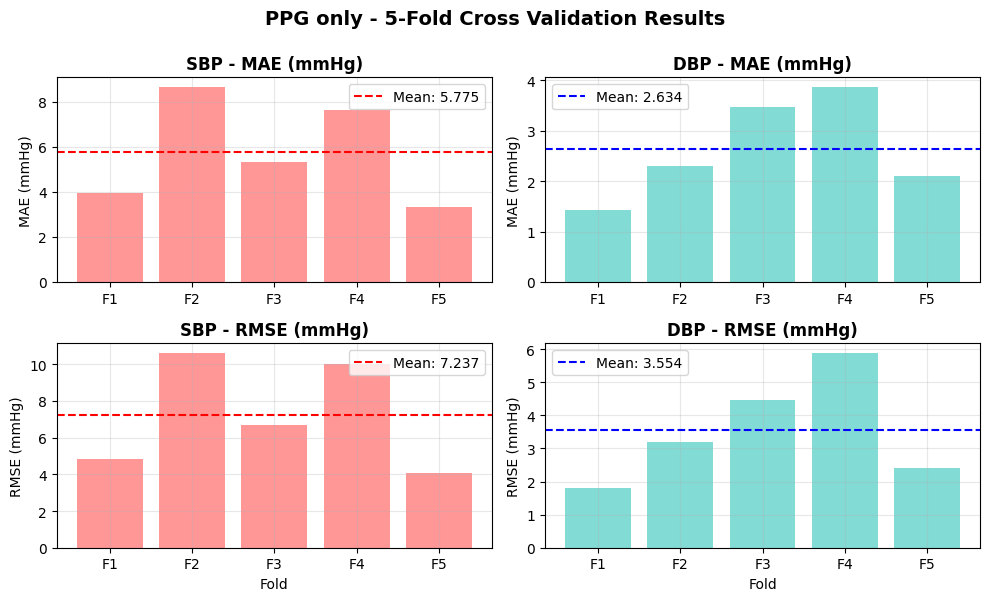

In [133]:
# ========================================================================
# 2. PPG only - 5-Fold 교차 검증
# ========================================================================


df_ppg, mae_sbp_ppg, mae_dbp_ppg, rmse_sbp_ppg, rmse_dbp_ppg = run_5fold(
    X_ppg, y_bp,
    build_fn=build_model_ppg,
    model_name="PPG only"
)

# PPG only 결과 그래프
plot_results(mae_sbp_ppg, mae_dbp_ppg, rmse_sbp_ppg, rmse_dbp_ppg,
             title="PPG only - 5-Fold Cross Validation Results")



ECG+PPG - 5-Fold 교차 검증

[Fold 1] Train:320 Val:40 Test:40
  SBP: MAE=2.813, RMSE=3.906
  DBP: MAE=0.974, RMSE=1.347

[Fold 2] Train:320 Val:40 Test:40
  SBP: MAE=7.799, RMSE=9.167
  DBP: MAE=2.307, RMSE=2.929

[Fold 3] Train:320 Val:40 Test:40
  SBP: MAE=3.458, RMSE=4.191
  DBP: MAE=2.431, RMSE=3.860

[Fold 4] Train:320 Val:40 Test:40
  SBP: MAE=8.944, RMSE=10.137
  DBP: MAE=3.085, RMSE=4.680

[Fold 5] Train:320 Val:40 Test:40
  SBP: MAE=3.357, RMSE=3.791
  DBP: MAE=1.329, RMSE=1.610

최종 결과
      Fold Train Val Test             SBP_MAE             DBP_MAE            SBP_RMSE            DBP_RMSE
    Fold 1   320  40   40               2.813               0.974               3.906               1.347
    Fold 2   320  40   40               7.799               2.307               9.167               2.929
    Fold 3   320  40   40               3.458               2.431               4.191                3.86
    Fold 4   320  40   40               8.944               3.085              

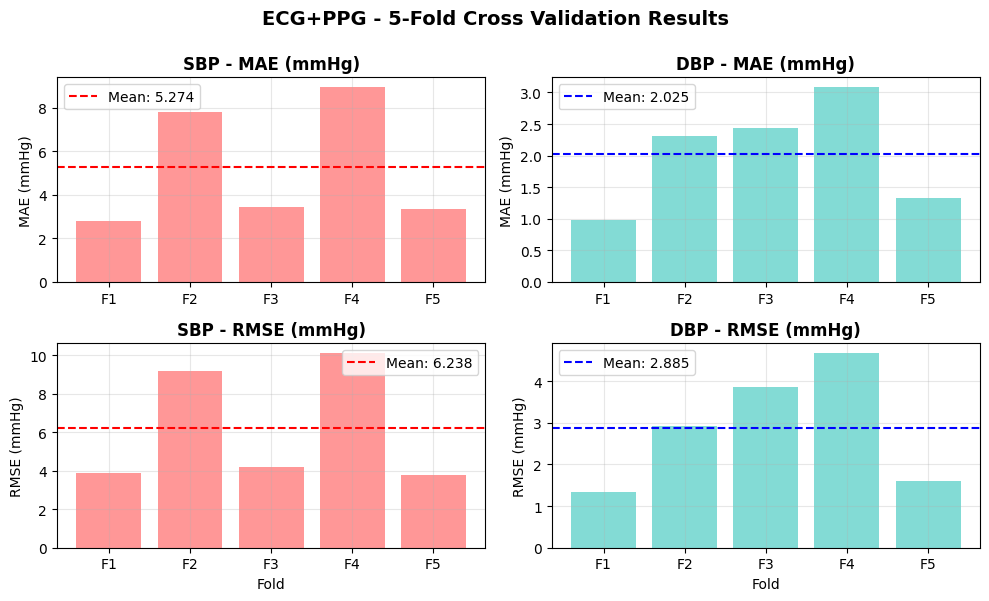

In [134]:
# ========================================================================
# 3. ECG+PPG - 5-Fold 교차 검증
# ========================================================================


X_ecg_ppg, y_bp = load_data(train_path, use_ecg=True)
X_ecg_ppg = X_ecg_ppg[:2000]
y_bp = y_bp[:2000]

df_ecg_ppg, mae_sbp_ecg, mae_dbp_ecg, rmse_sbp_ecg, rmse_dbp_ecg = run_5fold(
    X_ecg_ppg, y_bp,
    build_fn=build_model_ecg_ppg,
    model_name="ECG+PPG"
)


# ECG+PPG 결과 그래프
plot_results(mae_sbp_ecg, mae_dbp_ecg, rmse_sbp_ecg, rmse_dbp_ecg,
             title="ECG+PPG - 5-Fold Cross Validation Results")


환자 간 테스트 - PPG only
Train: (2000, 1250), Test: (2000, 1250)

----------------------------------------------------------------------
훈련 환자 기준 5-Fold, 테스트는 항상 다른 환자 전체
----------------------------------------------------------------------

[Fold 1] Train:320 Val:40 Test:2000

[Fold 2] Train:320 Val:40 Test:2000

[Fold 3] Train:320 Val:40 Test:2000

[Fold 4] Train:320 Val:40 Test:2000

[Fold 5] Train:320 Val:40 Test:2000

최종 결과 - PPG only
      Fold Train Val Test      SBP_MAE      DBP_MAE     SBP_RMSE     DBP_RMSE
    Fold 1   320  40 2000        15.32        9.612       18.603       11.328
    Fold 2   320  40 2000       14.271       10.133       16.506       12.094
    Fold 3   320  40 2000       14.961        9.294       17.953       11.038
    Fold 4   320  40 2000        16.23        9.301       19.303       11.006
    Fold 5   320  40 2000       14.955       13.666       17.393       16.113
Mean ± Std     -   -    - 15.147±0.639 10.401±1.661 17.952±0.965 12.316±1.939


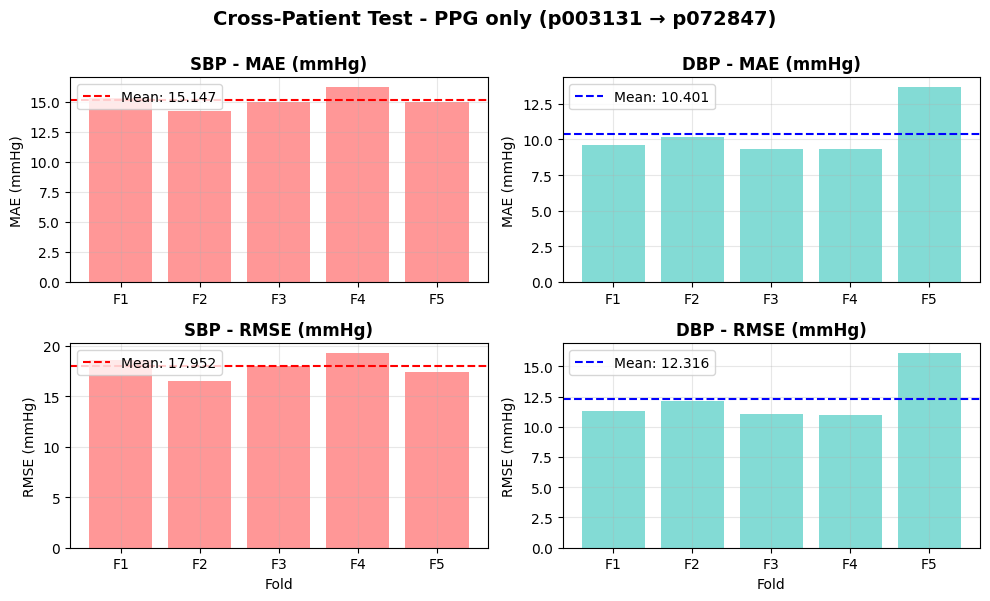

In [135]:
# ========================================================================
# 4. 환자 간 테스트 - PPG only
# ========================================================================


df_cross_ppg, mae_sbp_cross_ppg, mae_dbp_cross_ppg, rmse_sbp_cross_ppg, rmse_dbp_cross_ppg = \
    cross_patient_test(train_path, test_path, use_ecg=False)


# 환자 간 테스트 PPG 결과 그래프
plot_results(mae_sbp_cross_ppg, mae_dbp_cross_ppg, rmse_sbp_cross_ppg, rmse_dbp_cross_ppg,
             title="Cross-Patient Test - PPG only (p003131 → p072847)")


환자 간 테스트 - ECG+PPG
Train: (2000, 1250, 2), Test: (2000, 1250, 2)

----------------------------------------------------------------------
훈련 환자 기준 5-Fold, 테스트는 항상 다른 환자 전체
----------------------------------------------------------------------

[Fold 1] Train:320 Val:40 Test:2000

[Fold 2] Train:320 Val:40 Test:2000

[Fold 3] Train:320 Val:40 Test:2000

[Fold 4] Train:320 Val:40 Test:2000

[Fold 5] Train:320 Val:40 Test:2000

최종 결과 - ECG+PPG
      Fold Train Val Test      SBP_MAE      DBP_MAE     SBP_RMSE     DBP_RMSE
    Fold 1   320  40 2000       40.369       27.243        45.25       29.262
    Fold 2   320  40 2000       35.704       23.536       40.902       25.794
    Fold 3   320  40 2000       54.376       30.006       58.041       31.859
    Fold 4   320  40 2000       43.515       20.947       47.755       23.406
    Fold 5   320  40 2000       33.672       25.461       38.859        27.48
Mean ± Std     -   -    - 41.527±7.294 25.439±3.095 46.161±6.715 27.560±2.890


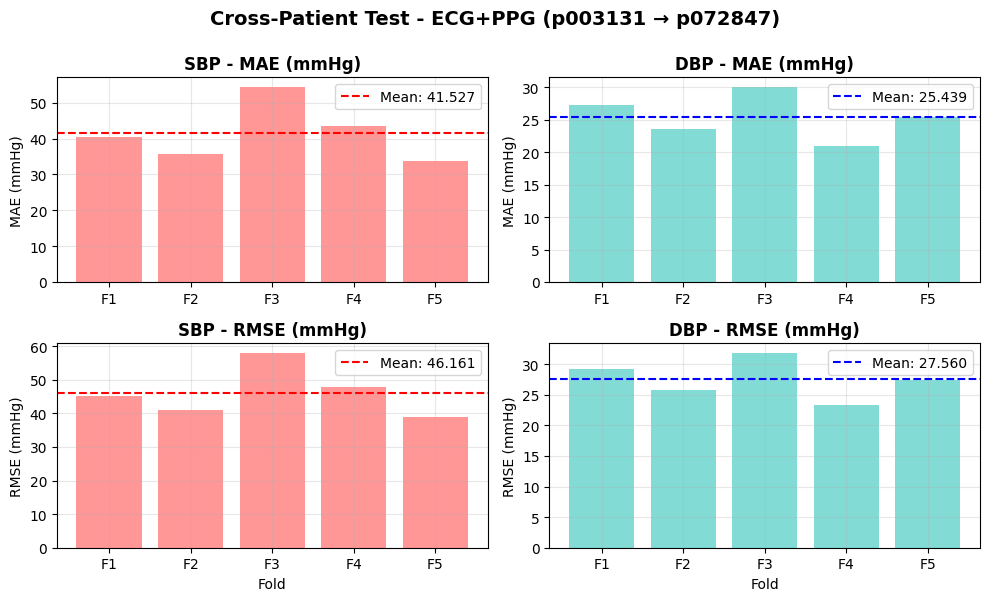

In [136]:
# ========================================================================
# 5. 환자 간 테스트 - ECG+PPG
# ========================================================================

df_cross_ecg, mae_sbp_cross_ecg, mae_dbp_cross_ecg, rmse_sbp_cross_ecg, rmse_dbp_cross_ecg = \
    cross_patient_test(train_path, test_path, use_ecg=True)

# 환자 간 테스트 ECG+PPG 결과 그래프
plot_results(mae_sbp_cross_ecg, mae_dbp_cross_ecg, rmse_sbp_cross_ecg, rmse_dbp_cross_ecg,
             title="Cross-Patient Test - ECG+PPG (p003131 → p072847)")